In [11]:
import sys
sys.path.append(r"C:\Users\mayan\AppData\Roaming\Python\Python312\site-packages")


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [13]:
# Step 1: Load data
df = pd.read_csv("traffic_2hr_intervals.csv", parse_dates=["datetime"])
df.sort_values(by=["location", "datetime"], inplace=True)

In [14]:
# Step 2: Select a location and only the 'flow' series
location_id = df["location"].unique()[0]
df_location = df[df["location"] == location_id].copy()
df_location.set_index("datetime", inplace=True)

flow_series = df_location["flow"]

In [15]:
# Step 3: Optional - resample to hourly/daily if needed
# flow_series = flow_series.resample("2H").mean()

In [16]:
# Step 4: Train-test split
train_size = int(len(flow_series) * 0.8)
train, test = flow_series[:train_size], flow_series[train_size:]

In [17]:
# Step 5: Fit ARIMA model
# You can tune the (p,d,q) values based on AIC/BIC or auto_arima
model = ARIMA(train, order=(3,1,2))  # p=3, d=1, q=2 (example)
model_fit = model.fit()

C:\Users\mayan\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 2h will be used.
  self._init_dates(dates, freq)
C:\Users\mayan\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 2h will be used.
  self._init_dates(dates, freq)
C:\Users\mayan\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 2h will be used.
  self._init_dates(dates, freq)
C:\Users\mayan\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\mayan\AppData\Roaming\Python\Python312\site-pa

In [18]:
# Step 6: Forecast
forecast = model_fit.forecast(steps=len(test))

# Step 7: Evaluate
mae = mean_absolute_error(test, forecast)
mse = mean_squared_error(test, forecast)
rmse = np.sqrt(mse)

print(f"ARIMA MAE: {mae:.2f}")
print(f"ARIMA RMSE: {rmse:.2f}")

ARIMA MAE: 113.69
ARIMA RMSE: 133.31


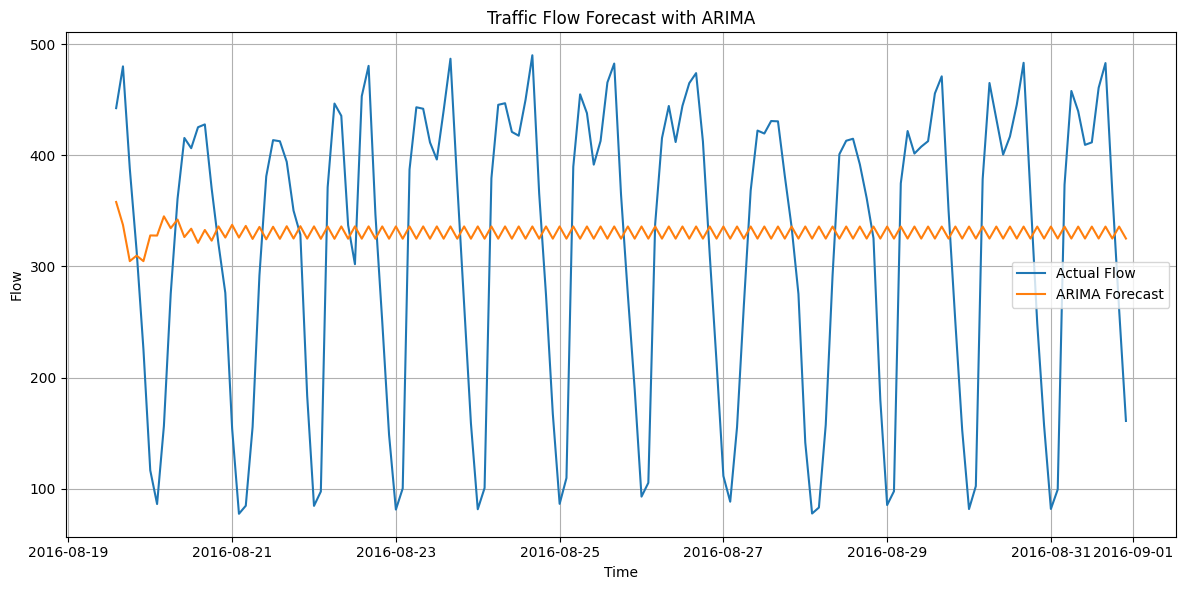

In [19]:
# Step 8: Plot
plt.figure(figsize=(12,6))
plt.plot(test.index, test.values, label='Actual Flow')
plt.plot(test.index, forecast, label='ARIMA Forecast')
plt.title("Traffic Flow Forecast with ARIMA")
plt.xlabel("Time")
plt.ylabel("Flow")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()